In [3]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn scikit-learn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf   # 수식(formula)으로 회귀를 쓰는 인터페이스
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지


warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", scipy.__version__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : 1.17.1


In [4]:
# [C2] ── 데이터 로드 — 모두 라이브러리가 제공하는 데이터셋 ─────────────
from sklearn.datasets import load_diabetes

# (1) scikit-learn 내장: 질병 진행도 (설명변수는 표준화되어 있음)
dia = load_diabetes(as_frame=True)
df = dia.frame                       # 컬럼: age sex bmi bp s1..s6 target

# (2) statsmodels 내장: 소득 → 식료품 지출 (단위가 살아 있는 데이터)
engel = sm.datasets.engel.load_pandas().data          # income, foodexp (벨기에 프랑)

# (3) statsmodels 내장: 거시경제 (다중공선성 교과서)
longley = sm.datasets.longley.load_pandas().data

# (4) Rdatasets: 캘리포니아 학군 420곳
ca = sm.datasets.get_rdataset("CASchools", "AER").data.copy()
ca["testscr"] = (ca["read"] + ca["math"]) / 2          # 읽기·수학 평균 점수 (결과 변수)
ca["str_ratio"] = ca["students"] / ca["teachers"]      # 학생-교사비 (교사 1명당 학생 수)

print("diabetes :", df.shape, "| 컬럼:", list(df.columns))
print("engel    :", engel.shape, "| 컬럼:", list(engel.columns),
      f"| 소득 평균 {engel['income'].mean():.0f}, 식료품 지출 평균 {engel['foodexp'].mean():.0f}")
print("CASchools:", ca.shape, "| 점수 평균 %.1f, 학생-교사비 평균 %.1f"
      % (ca["testscr"].mean(), ca["str_ratio"].mean()))
print("longley  :", longley.shape, "| 컬럼:", list(longley.columns))
print()
print("diabetes 미리보기:")
print(df[["age", "bmi", "bp", "s5", "target"]].head().round(3))

diabetes : (442, 11) | 컬럼: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
engel    : (235, 2) | 컬럼: ['income', 'foodexp'] | 소득 평균 982, 식료품 지출 평균 624
CASchools: (420, 16) | 점수 평균 654.2, 학생-교사비 평균 19.6
longley  : (16, 7) | 컬럼: ['TOTEMP', 'GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']

diabetes 미리보기:
     age    bmi     bp     s5  target
0  0.038  0.062  0.022  0.020   151.0
1 -0.002 -0.051 -0.026 -0.068    75.0
2  0.085  0.044 -0.006  0.003   141.0
3 -0.089 -0.012 -0.037  0.023   206.0
4  0.005 -0.036  0.022 -0.032   135.0


Pearson  r = 0.586  (p = 3.47e-42)   선형 관계의 세기
Spearman ρ = 0.561  (p = 4.57e-38)   순위 관계의 세기


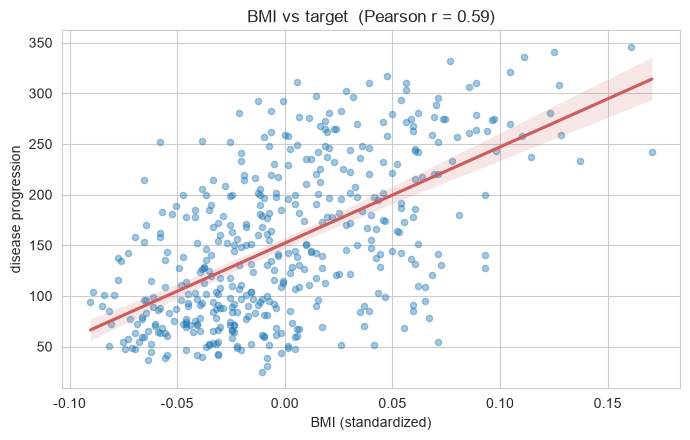

In [5]:
# [C3] diabetes: bmi와 질병 진행도(target)의 상관 — Pearson vs Spearman
x = df["bmi"]; y = df["target"]
r_p, p_p = stats.pearsonr(x, y)                                   # Pearson 상관 — '직선' 관계의 세기 (-1~1)
r_s, p_s = stats.spearmanr(x, y)                                  # Spearman 상관 — 순위 기반, 곡선이어도 단조면 잡아냄
print(f"Pearson  r = {r_p:.3f}  (p = {p_p:.2e})   선형 관계의 세기")
print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.2e})   순위 관계의 세기")

fig, ax = plt.subplots(figsize=(7, 4.5))                          # 그래프 하나를 그릴 도화지 준비
sns.regplot(x=x, y=y, ax=ax, scatter_kws=dict(alpha=0.4, s=20), line_kws=dict(color="indianred"))  # 산점도 + 회귀선을 한 번에
ax.set_xlabel("BMI (standardized)"); ax.set_ylabel("disease progression")
ax.set_title(f"BMI vs target  (Pearson r = {r_p:.2f})")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

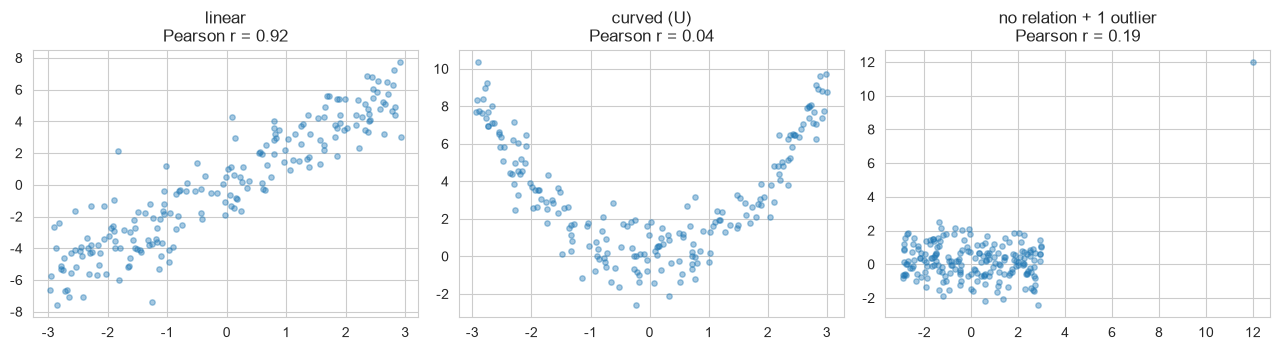

In [6]:
# [C4] 상관계수의 함정 — 같은 r=0 근처라도 관계는 천차만별 (개념 시연)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 200
x1 = np.random.uniform(-3, 3, n); y1 = 2*x1 + np.random.normal(0, 1.5, n)   # 선형
x2 = np.random.uniform(-3, 3, n); y2 = x2**2 + np.random.normal(0, 1, n)    # 곡선(U자)
x3 = np.random.uniform(-3, 3, n); y3 = np.random.normal(0, 1, n)            # 무관계
x3[0], y3[0] = 12, 12                                                       # 이상치 1개

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))                 # 그림 한 장에 그래프 3개(1행 3열)
for ax, xx, yy, t in zip(axes, [x1, x2, x3], [y1, y2, y3],
                         ["linear", "curved (U)", "no relation + 1 outlier"]):
    ax.scatter(xx, yy, alpha=0.4, s=15)
    ax.set_title(f"{t}\nPearson r = {stats.pearsonr(xx, yy)[0]:.2f}")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

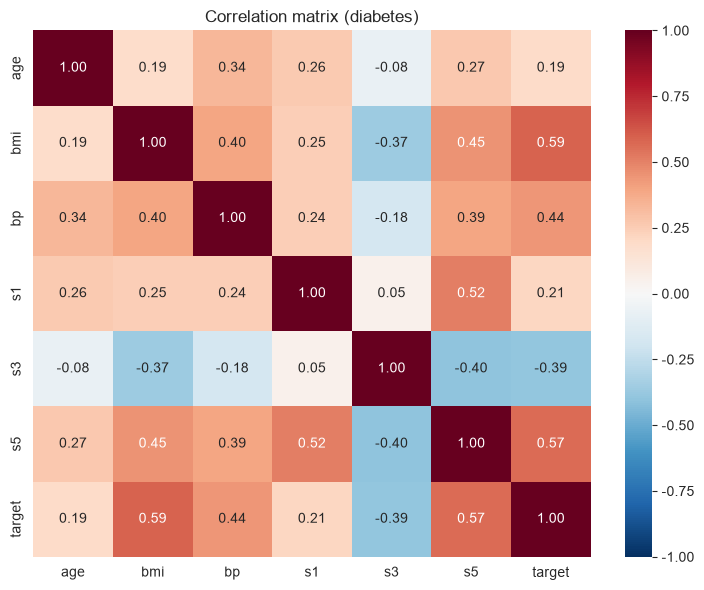

In [7]:
# [C5] 여러 변수의 상관을 한눈에 — 상관 행렬 히트맵 (이해 후 탐색이므로 seaborn)
corr = df[["age", "bmi", "bp", "s1", "s3", "s5", "target"]].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))                          # 그래프 하나를 그릴 도화지 준비
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)  # 상관 행렬을 색으로 — 진할수록 강한 상관
ax.set_title("Correlation matrix (diabetes)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

Pearson  r = 0.836   (곡선이라 다소 과소평가)
Spearman ρ = 0.959   (단조 증가를 강하게 포착)


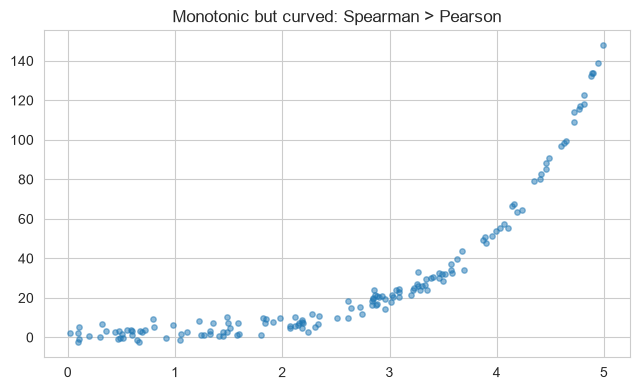

In [8]:
# [C6] 단조-비선형 관계: Pearson은 과소평가, Spearman은 제대로 잡는다
np.random.seed(0)                                                 # 재현성: 난수를 항상 같게 고정
x = np.sort(np.random.uniform(0, 5, 150))
y = np.exp(x) + np.random.normal(0, 3, 150)     # 지수적으로 증가 (곡선이지만 단조 증가)
print(f"Pearson  r = {stats.pearsonr(x, y)[0]:.3f}   (곡선이라 다소 과소평가)")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)
print(f"Spearman ρ = {stats.spearmanr(x, y)[0]:.3f}   (단조 증가를 강하게 포착)")  # Spearman 상관 — 순위 기반, 곡선이어도 단조면 잡아냄
fig, ax = plt.subplots(figsize=(6.5, 4)); ax.scatter(x, y, alpha=0.5, s=15)  # 그래프 하나를 그릴 도화지 준비
ax.set_title("Monotonic but curved: Spearman > Pearson"); plt.tight_layout(); plt.show()  # 그래프 간격 자동 정리 후 출력

In [9]:
# 1) diabetes에서 혈압(bp)과 질병 진행도(target)의 Pearson·Spearman 상관
from scipy import stats

pearson_r, pearson_p = stats.pearsonr(df["bp"], df["target"])
spearman_r, spearman_p = stats.spearmanr(df["bp"], df["target"])

print(f"Pearson  상관계수: r = {pearson_r:.4f}, p-value = {pearson_p:.4e}")
print(f"Spearman 상관계수: r = {spearman_r:.4f}, p-value = {spearman_p:.4e}")

Pearson  상관계수: r = 0.4415, p-value = 1.6494e-22
Spearman 상관계수: r = 0.4162, p-value = 5.9928e-20


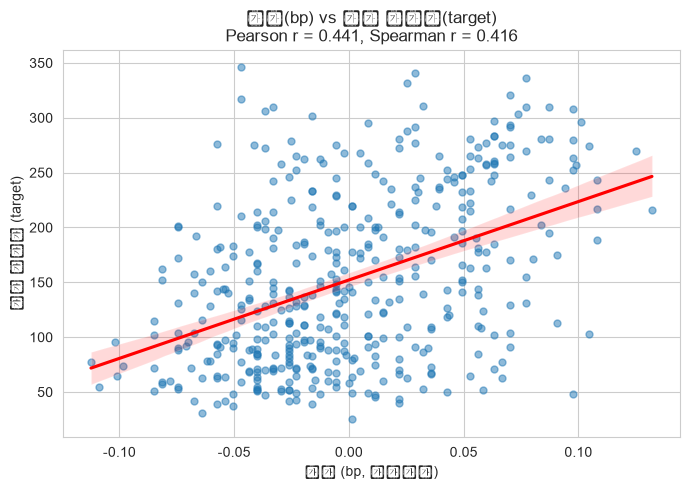

In [10]:
# 2) 산점도(regplot)로 두 변수의 관계 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="bp",
    y="target",
    scatter_kws={"alpha": 0.5, "s": 25},
    line_kws={"color": "red"}
)
plt.title(f"혈압(bp) vs 질병 진행도(target)\nPearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}")
plt.xlabel("혈압 (bp, 표준화됨)")
plt.ylabel("질병 진행도 (target)")
plt.tight_layout()
plt.show()

In [11]:
# [C8] 허위상관 시뮬레이션 — 교란변수 Z가 X와 Y를 동시에 움직인다 (개념 시연)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 300
Z = np.random.normal(0, 1, n)            # 숨은 공통 원인 (예: 기온)
X = 2*Z + np.random.normal(0, 0.5, n)    # 아이스크림 판매  (Z가 원인)
Y = 3*Z + np.random.normal(0, 0.5, n)    # 익사 사고 수      (Z가 원인)
# X와 Y 사이에는 '직접' 인과가 없지만...
r_xy = stats.pearsonr(X, Y)[0]                                    # Pearson 상관 — '직선' 관계의 세기 (-1~1)
print(f"X(아이스크림)와 Y(익사)의 상관 r = {r_xy:.3f}  ← 매우 강함!")
print("그러나 X→Y 직접 인과는 없습니다. 둘 다 Z(기온)가 움직인 결과일 뿐.")

# Z의 구간별로 나눠 보면 X-Y 관계가 사라진다 (Z를 '통제'하면)
g = pd.qcut(Z, 3, labels=["저", "중", "고"])                         # 값을 같은 크기의 구간으로 나눠 범주화
for lvl in ["저", "중", "고"]:
    mask = (g == lvl)
    print(f"  Z={lvl} 구간 안에서 X-Y 상관 = {stats.pearsonr(X[mask], Y[mask])[0]:.3f}")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)

X(아이스크림)와 Y(익사)의 상관 r = 0.956  ← 매우 강함!
그러나 X→Y 직접 인과는 없습니다. 둘 다 Z(기온)가 움직인 결과일 뿐.
  Z=저 구간 안에서 X-Y 상관 = 0.845
  Z=중 구간 안에서 X-Y 상관 = 0.567
  Z=고 구간 안에서 X-Y 상관 = 0.894


In [12]:
# [C9] 단순 회귀 — BMI로 질병 진행도 설명 (statsmodels OLS)
X = sm.add_constant(df["bmi"])      # 절편(beta0)을 위해 상수항 추가
y = df["target"]
model = sm.OLS(y, X).fit()                                        # 최소제곱 회귀 적합
print(model.summary().tables[1])     # 계수 표
print(f"\nR² = {model.rsquared:.3f}   (질병 진행도 변동의 약 {model.rsquared*100:.0f}%를 BMI가 설명)")
print(f"기울기 β1 = {model.params['bmi']:.1f}  → BMI가 1(표준화 단위) 늘면 진행도가 평균 {model.params['bmi']:.0f} 증가")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.000     146.289     157.978
bmi          949.4353     62.515     15.187      0.000     826.570    1072.301

R² = 0.344   (질병 진행도 변동의 약 34%를 BMI가 설명)
기울기 β1 = 949.4  → BMI가 1(표준화 단위) 늘면 진행도가 평균 949 증가


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.4754     15.957      9.242      0.000     116.037     178.914
income         0.4852      0.014     33.772      0.000       0.457       0.513

회귀식: 식료품지출 = 147.5 + 0.485 × 소득
해석  : 소득이 **100프랑** 늘면 식료품 지출은 평균 **48.5프랑** 늘어난다
        (소득이 0일 때의 예측 지출 = 147프랑 — 기초 식비에 해당하는 절편)
R² = 0.830  → 식료품 지출 변동의 약 83%를 소득이 설명

[엥겔의 법칙 확인] 식료품 지출이 소득에서 차지하는 비중
  소득 하위 절반: 68.6%   소득 상위 절반: 62.5%


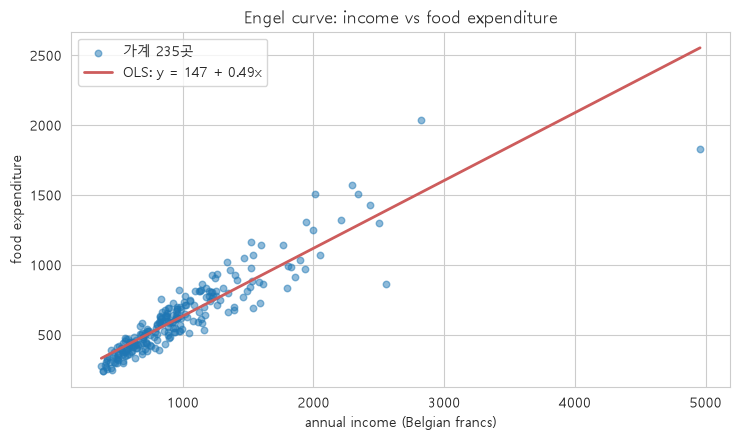

In [14]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# [C9b] 단순 회귀 — 소득으로 식료품 지출 설명 (단위가 있는 실데이터)
Xe = sm.add_constant(engel["income"])                             # 절편(β0)을 위해 상수항 1 열을 추가
me = sm.OLS(engel["foodexp"], Xe).fit()                           # 최소제곱 회귀 적합
print(me.summary().tables[1])                                     # 회귀 결과에서 '계수 표'만 출력

b0, b1 = me.params["const"], me.params["income"]
print(f"\n회귀식: 식료품지출 = {b0:.1f} + {b1:.3f} × 소득")
print(f"해석  : 소득이 **100프랑** 늘면 식료품 지출은 평균 **{b1*100:.1f}프랑** 늘어난다")
print(f"        (소득이 0일 때의 예측 지출 = {b0:.0f}프랑 — 기초 식비에 해당하는 절편)")
print(f"R² = {me.rsquared:.3f}  → 식료품 지출 변동의 약 {me.rsquared*100:.0f}%를 소득이 설명")

# 엥겔의 법칙: 소득이 늘수록 '식료품 비중'은 줄어드는가?
share_low  = (engel.loc[engel["income"] <= engel["income"].median(), "foodexp"]
              / engel.loc[engel["income"] <= engel["income"].median(), "income"]).mean()
share_high = (engel.loc[engel["income"] >  engel["income"].median(), "foodexp"]
              / engel.loc[engel["income"] >  engel["income"].median(), "income"]).mean()
print(f"\n[엥겔의 법칙 확인] 식료품 지출이 소득에서 차지하는 비중")
print(f"  소득 하위 절반: {share_low:.1%}   소득 상위 절반: {share_high:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))                        # 그래프 하나를 그릴 도화지 준비
ax.scatter(engel["income"], engel["foodexp"], alpha=0.5, s=22, label="가계 235곳")
xs = np.linspace(engel["income"].min(), engel["income"].max(), 100)  # 구간을 균등 간격으로 쪼갠 x축 값
ax.plot(xs, b0 + b1 * xs, color="indianred", lw=2, label=f"OLS: y = {b0:.0f} + {b1:.2f}x")
ax.set_xlabel("annual income (Belgian francs)"); ax.set_ylabel("food expenditure")
ax.set_title("Engel curve: income vs food expenditure"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

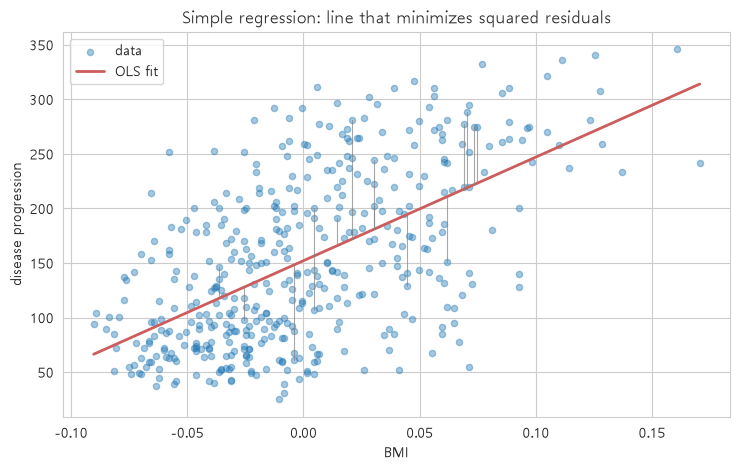

In [15]:
# [C10] 회귀선과 데이터, 그리고 '오차(잔차)'를 함께 그려보기
fig, ax = plt.subplots(figsize=(7.5, 4.8))                        # 그래프 하나를 그릴 도화지 준비
ax.scatter(df["bmi"], y, alpha=0.4, s=20, label="data")
xs = np.linspace(df["bmi"].min(), df["bmi"].max(), 100)           # 구간을 균등 간격으로 쪼갠 x축 값
ax.plot(xs, model.params["const"] + model.params["bmi"]*xs, color="indianred", lw=2, label="OLS fit")
# 잔차(점에서 선까지의 세로 거리) 몇 개를 표시
for i in range(0, len(df), 30):
    xi, yi = df["bmi"].iloc[i], y.iloc[i]
    yhat = model.params["const"] + model.params["bmi"]*xi
    ax.plot([xi, xi], [yi, yhat], color="gray", lw=0.8, alpha=0.7)
ax.set_xlabel("BMI"); ax.set_ylabel("disease progression"); ax.legend()
ax.set_title("Simple regression: line that minimizes squared residuals")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [16]:
# [C11] 새 입력에 대한 예측 — 평균 신뢰구간 vs 예측구간
Xs = sm.add_constant(df["bmi"]); ms = sm.OLS(df["target"], Xs).fit()  # 절편(β0)을 위해 상수항 1 열을 추가
q = df["bmi"].quantile([0.25, 0.5, 0.75]).values                  # 분위수 — 정렬했을 때 몇 % 지점의 값
new = pd.DataFrame({"const": [1.0]*3, "bmi": q})
pr = ms.get_prediction(new).summary_frame(alpha=0.05)
out = pd.DataFrame({
    "bmi": q.round(3),
    "예측 ŷ": pr["mean"].round(1),
    "평균 95%CI": [f"[{l:.0f}, {u:.0f}]" for l, u in zip(pr["mean_ci_lower"], pr["mean_ci_upper"])],
    "예측구간": [f"[{l:.0f}, {u:.0f}]" for l, u in zip(pr["obs_ci_lower"], pr["obs_ci_upper"])],
})
print(out.to_string(index=False))
print("\n→ 예측구간(개인)이 평균 신뢰구간보다 훨씬 넓은 것을 확인하세요.")

   bmi  예측 ŷ   평균 95%CI      예측구간
-0.034 119.6 [112, 127] [-3, 243]
-0.007 145.2 [139, 151] [22, 268]
 0.031 181.8 [175, 189] [59, 305]

→ 예측구간(개인)이 평균 신뢰구간보다 훨씬 넓은 것을 확인하세요.


In [17]:
# [C9-2] 단순 회귀 — s5(혈청 지표)로 질병 진행도 설명 (statsmodels OLS)
X_s5 = sm.add_constant(df["s5"])    # 절편(beta0)을 위해 상수항 추가
y = df["target"]
model_s5 = sm.OLS(y, X_s5).fit()                                   # 최소제곱 회귀 적합
print(model_s5.summary().tables[1])  # 계수 표
print(f"\nR² = {model_s5.rsquared:.3f}   (질병 진행도 변동의 약 {model_s5.rsquared*100:.0f}%를 s5가 설명)")
print(f"기울기 β1 = {model_s5.params['s5']:.1f}  → s5가 1(표준화 단위) 늘면 진행도가 평균 {model_s5.params['s5']:.0f} 증가")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      3.027     50.263      0.000     146.185     158.082
s5           916.1374     63.634     14.397      0.000     791.072    1041.202

R² = 0.320   (질병 진행도 변동의 약 32%를 s5가 설명)
기울기 β1 = 916.1  → s5가 1(표준화 단위) 늘면 진행도가 평균 916 증가


In [18]:
# 2) 기울기와 R²를 BMI 모델과 비교
print("=== BMI 모델 vs s5 모델 비교 ===")
print(f"{'':12}{'기울기(β1)':>15}{'R²':>10}")
print(f"{'bmi':12}{model.params['bmi']:>15.1f}{model.rsquared:>10.3f}")
print(f"{'s5':12}{model_s5.params['s5']:>15.1f}{model_s5.rsquared:>10.3f}")

if model_s5.rsquared > model.rsquared:
    print(f"\n→ s5가 bmi보다 target의 변동을 더 많이 설명함 (R² 차이: {model_s5.rsquared - model.rsquared:.3f})")
else:
    print(f"\n→ bmi가 s5보다 target의 변동을 더 많이 설명함 (R² 차이: {model.rsquared - model_s5.rsquared:.3f})")

=== BMI 모델 vs s5 모델 비교 ===
                    기울기(β1)        R²
bmi                   949.4     0.344
s5                    916.1     0.320

→ bmi가 s5보다 target의 변동을 더 많이 설명함 (R² 차이: 0.024)


In [19]:
import numpy as np

np.random.seed(42)
n_boot = 1000
diffs = []

for _ in range(n_boot):
    idx = np.random.choice(len(df), size=len(df), replace=True)
    sample = df.iloc[idx]
    
    r2_bmi = sm.OLS(sample["target"], sm.add_constant(sample["bmi"])).fit().rsquared
    r2_s5 = sm.OLS(sample["target"], sm.add_constant(sample["s5"])).fit().rsquared
    diffs.append(r2_bmi - r2_s5)

diffs = np.array(diffs)
print(f"R² 차이(bmi - s5) 평균: {diffs.mean():.4f}")
print(f"95% 구간: [{np.percentile(diffs, 2.5):.4f}, {np.percentile(diffs, 97.5):.4f}]")
print(f"차이가 0보다 작은 비율: {(diffs < 0).mean()*100:.1f}%")

R² 차이(bmi - s5) 평균: 0.0244
95% 구간: [-0.0615, 0.1168]
차이가 0보다 작은 비율: 29.2%


In [20]:
# [C13] 다중 회귀 — 여러 지표로 질병 진행도 설명
features = ["age", "sex", "bmi", "bp", "s1", "s3", "s5"]
X = sm.add_constant(df[features])                                 # 절편(β0)을 위해 상수항 1 열을 추가
y = df["target"]
mfit = sm.OLS(y, X).fit()                                         # 최소제곱 회귀 적합
print(mfit.summary().tables[1])                                   # 회귀 결과에서 '계수 표'만 출력
print(f"\nR² = {mfit.rsquared:.3f},  조정 R² = {mfit.rsquared_adj:.3f}")  # 조정 R² — 변수 수에 벌점을 준 값
print(f"F-검정: F = {mfit.fvalue:.1f}, p = {mfit.f_pvalue:.2e}  → 모델 전체가 유의")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.579     58.990      0.000     147.065     157.202
age            1.1087     59.239      0.019      0.985    -115.322     117.540
sex         -226.6174     60.878     -3.722      0.000    -346.270    -106.965
bmi          537.5551     65.517      8.205      0.000     408.784     666.326
bp           327.9901     64.468      5.088      0.000     201.282     454.699
s1          -136.7962     68.103     -2.009      0.045    -270.649      -2.943
s3          -240.6993     69.806     -3.448      0.001    -377.898    -103.500
s5           555.5010     77.118      7.203      0.000     403.929     707.073

R² = 0.513,  조정 R² = 0.505
F-검정: F = 65.4, p = 5.77e-64  → 모델 전체가 유의


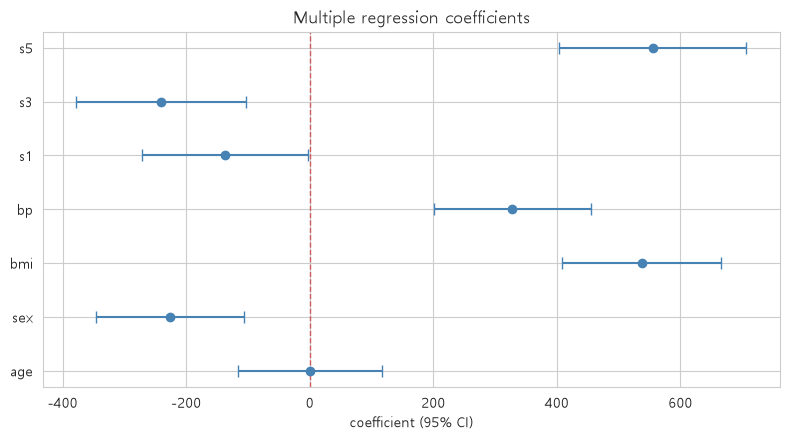

In [21]:
# [C14] 계수와 95% 신뢰구간을 한눈에 — forest plot (개념 도식: matplotlib 직접 구성)
params = mfit.params.drop("const")
ci = mfit.conf_int().drop("const")                                # 계수의 95% 신뢰구간
fig, ax = plt.subplots(figsize=(8, 4.5))                          # 그래프 하나를 그릴 도화지 준비
yloc = np.arange(len(params))                                     # 정수 눈금 배열 생성
ax.errorbar(params.values, yloc,                                  # 오차막대(신뢰구간) 표시
            xerr=[params.values - ci[0].values, ci[1].values - params.values],
            fmt="o", color="steelblue", capsize=4)
ax.axvline(0, color="indianred", ls="--", lw=1)     # 0 = 효과 없음
ax.set_yticks(yloc); ax.set_yticklabels(params.index)
ax.set_xlabel("coefficient (95% CI)"); ax.set_title("Multiple regression coefficients")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력